# Breakout v5 — Multi-faceted experiment analysis

Compare the runs under `experiments/` along several axes, reading only the
artifacts training/evaluation already produced (no re-training, no re-eval).
Everything here calls the reusable core in [`src/analysis.py`](../src/analysis.py)
and the plot functions in [`scripts/plot_results.py`](../scripts/plot_results.py),
so the figures are identical to `python scripts/plot_results.py --analysis`.

**Axes covered**
1. Algorithm (DQN / Double / Dueling / A2C / PPO)
2. Seed (cross-seed aggregate, where ≥3 seeds exist)
3. Timestep budget (1M / 2M / 10M / 50M)
4. Hyperparameters (response curves from `ablation_0603`)
5. Sample efficiency · 6. Compute cost · 7. Behavior/shape · 8. Statistical significance

**Data caveat that shapes every conclusion:** only the `1m` group has a real
seed sweep (7/77/777). `10m`/`50m`/`ablation_0603` are essentially single-seed,
so their uncertainty is the 100-episode bootstrap CI — *evaluation* variance,
**not** training-seed variance. The cross-seed aggregate below makes this explicit.

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")

# Work whether the notebook is launched from the repo root or from reports/.
ROOT = Path.cwd()
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import pandas as pd
from IPython.display import Image, display
from src import analysis as A
from scripts import plot_results as P  # plot functions (write PNG, shown inline)

pd.set_option("display.width", 180); pd.set_option("display.max_columns", 40)

# Pick which experiment groups to analyze (edit freely).
GROUPS = ["10m", "2m", "1m", "50m"]
EXPERIMENTS = [ROOT / "experiments" / g for g in GROUPS if (ROOT / "experiments" / g).exists()]
OUT = ROOT / "reports" / "figures" / "notebook"; OUT.mkdir(parents=True, exist_ok=True)

records = A.dedup_latest(A.discover_runs(EXPERIMENTS))
print(f"{len(records)} runs from {[p.name for p in EXPERIMENTS]}")

def show(fn, name, recs=None, **kw):
    """Render a plot_results plot fn to PNG and display it inline."""
    out = OUT / f"{name}.png"
    fn(records if recs is None else recs, out, **kw)
    display(Image(str(out)))

79 runs from ['10m', '2m', '1m', '50m']


## Master metrics table
One row per run with every criterion (final score, sample efficiency, stability,
compute, behavior). This is the single source the plots draw from.

In [2]:
table = A.runs_table(records, threshold=50)
table.round(2)

,run,label,algo,variant,seed,budget,bucket,final_mean,final_std,final_median,final_min,final_max,final_ci95_low,final_ci95_high,auc_mean_reward,steps_to_threshold,final,best,tail_std,tail_cv,drawdown,fps,wall_clock_hours,train_steps,mean_length,cap_rate,skew,reward_mean,reward_median,n_episodes
0,2026-06-07_092822_ddqn_seed7,dqn[double],dqn,ddqn,7,10000000,10m,26.64,14.80,38.0,8.0,43.0,23.81,29.51,17.74,NaN,20.33,32.00,1.93,0.09,11.67,7636.25,1.49,40824460.0,108000.00,1.00,-0.08,26.64,38.0,100
1,2026-05-21_225125_a2c_seed7,a2c,a2c,baseline,7,10000000,10m,386.03,19.86,379.0,358.0,416.0,382.10,389.66,175.69,2000000.0,290.00,387.00,40.07,0.12,97.00,7569.61,1.49,40522921.0,85759.74,0.78,0.13,386.03,379.0,100
2,2026-05-22_002124_ppo_seed7,ppo,ppo,baseline,7,10000000,10m,261.77,101.51,281.0,110.0,365.0,240.98,281.24,136.19,3000000.0,117.00,323.00,56.31,0.29,206.00,7462.46,1.51,40536030.0,108000.00,1.00,-0.65,261.77,281.0,100
3,2026-06-07_075626_dqn_baseline_seed7,dqn,dqn,baseline,7,10000000,10m,75.73,25.03,87.0,31.0,99.0,70.73,80.32,23.31,6000000.0,33.67,62.33,7.00,0.29,28.67,7491.91,1.51,40855682.0,28646.39,0.22,-1.00,75.73,87.0,100
4,2026-06-03_104952_a2c_adam_seed7,a2c[adam],a2c,adam,7,10000000,10m,305.84,92.63,360.0,161.0,370.0,287.38,323.95,184.07,2000000.0,208.67,363.33,71.46,0.23,154.67,7292.37,1.54,40543835.0,108000.00,1.00,-0.92,305.84,360.0,100
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74,2026-05-29_135300_a2c_seed7,a2c,a2c,baseline,7,50000000,50m,378.28,13.12,369.0,367.0,399.0,375.78,380.86,141.09,3000000.0,1.00,406.00,0.47,1.41,405.00,7438.65,7.70,206119811.0,108000.00,1.00,0.80,378.28,369.0,100
75,2026-06-01_151746_ppo_seed0,ppo,ppo,baseline,0,50000000,50m,307.00,89.87,263.0,197.0,422.0,289.94,323.76,193.85,4000000.0,20.00,403.50,4.59,0.25,383.50,7521.68,7.46,201869304.0,108000.00,1.00,0.08,307.00,263.0,100
76,2026-06-02_092956_ppo_seed7,ppo,ppo,baseline,7,50000000,50m,369.27,18.70,369.0,348.0,401.0,365.72,372.98,184.04,2000000.0,8.00,385.00,66.24,1.18,377.00,7478.82,4.44,119517599.0,85923.64,0.78,0.67,369.27,369.0,100
77,2026-06-02_185902_dqn_baseline_seed7,dqn,dqn,baseline,7,50000000,50m,368.67,53.61,395.0,282.0,418.0,358.12,378.35,104.92,4000000.0,165.00,404.50,69.70,1.04,239.50,NaN,NaN,NaN,80966.59,0.73,-0.92,368.67,395.0,100


## Axis 1+2 — Algorithm & seed: cross-seed aggregate
Bars = mean ±95% bootstrap CI; = IQM (robust); black dots = individual seeds.
`n=` in each x-label is the number of training seeds — trust wide-`n` bars, read
`n=1` bars as anecdotes.

[plot] saved /home/lch/ws/Breakout_Final_Project_Pack/reports/figures/notebook/seed_aggregate.png


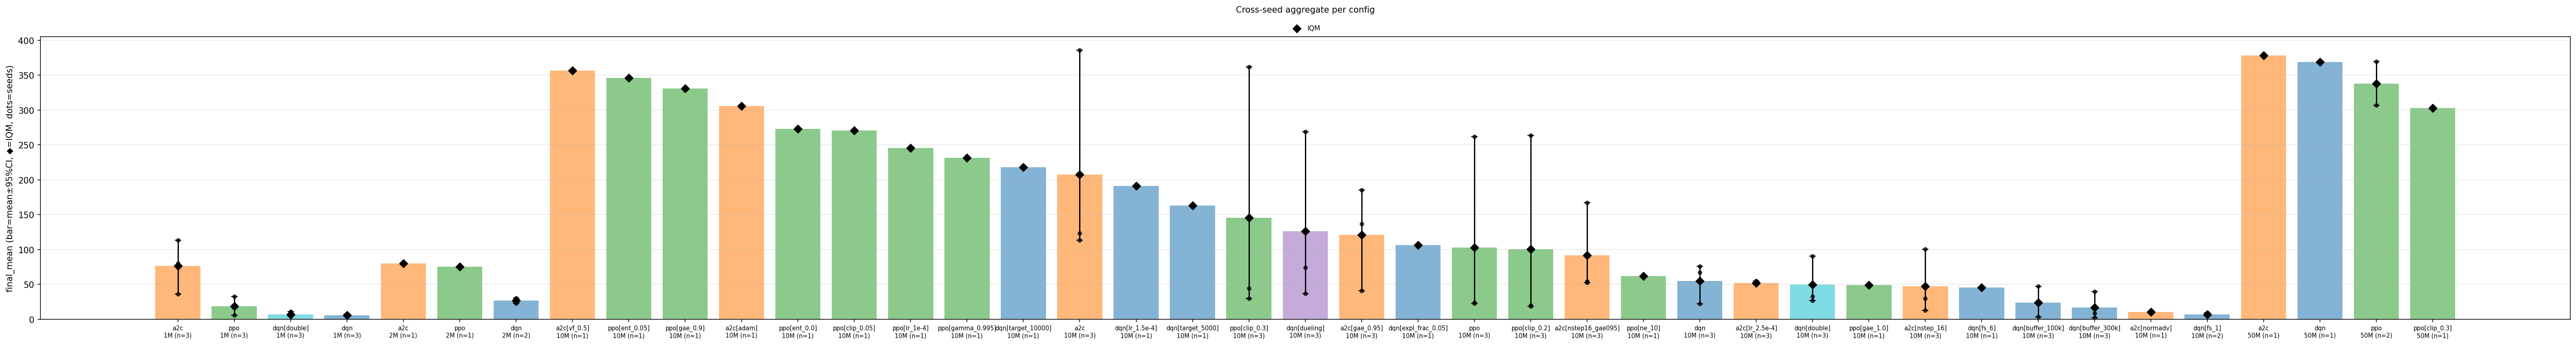

,label,budget,budget_str,n_seeds,seeds,mean,mean_ci_low,mean_ci_high,iqm,iqm_ci_low,iqm_ci_high,std_across_seeds
0,a2c,1000000,1M,3,"[7, 77, 777]",76.31,36.01,113.08,76.31,36.01,113.08,31.56
26,ppo,1000000,1M,3,"[7, 77, 777]",18.72,6.01,32.71,18.72,6.01,32.71,10.94
17,dqn[double],1000000,1M,3,"[7, 77, 777]",6.70,3.78,10.92,6.70,3.78,10.92,3.05
11,dqn,1000000,1M,3,"[7, 77, 777]",5.94,3.91,7.71,5.94,3.91,7.71,1.56
1,a2c,2000000,2M,1,[7],79.84,NaN,NaN,79.84,NaN,NaN,0.00
27,ppo,2000000,2M,1,[7],75.23,NaN,NaN,75.23,NaN,NaN,0.00
12,dqn,2000000,2M,2,"[7, 77]",26.70,22.92,30.47,26.70,NaN,NaN,3.77
10,a2c[vf_0.5],10000000,10M,1,[7],356.50,NaN,NaN,356.50,NaN,NaN,0.00
34,ppo[ent_0.05],10000000,10M,1,[7],346.14,NaN,NaN,346.14,NaN,NaN,0.00
36,ppo[gae_0.9],10000000,10M,1,[7],331.21,NaN,NaN,331.21,NaN,NaN,0.00


In [3]:
show(P.plot_seed_aggregate, "seed_aggregate")
# The cross-seed table (only 1m has >=3 seeds):
A.aggregate_by_config(records).round(2)

## Axis 1 — Score distribution shape (violin + ECDF)
A box/mean hides skew, multimodality, and the 108000-step time-cap pile-up.
Restricting to a single budget keeps the comparison fair.

[plot] saved /home/lch/ws/Breakout_Final_Project_Pack/reports/figures/notebook/violin_1m.png


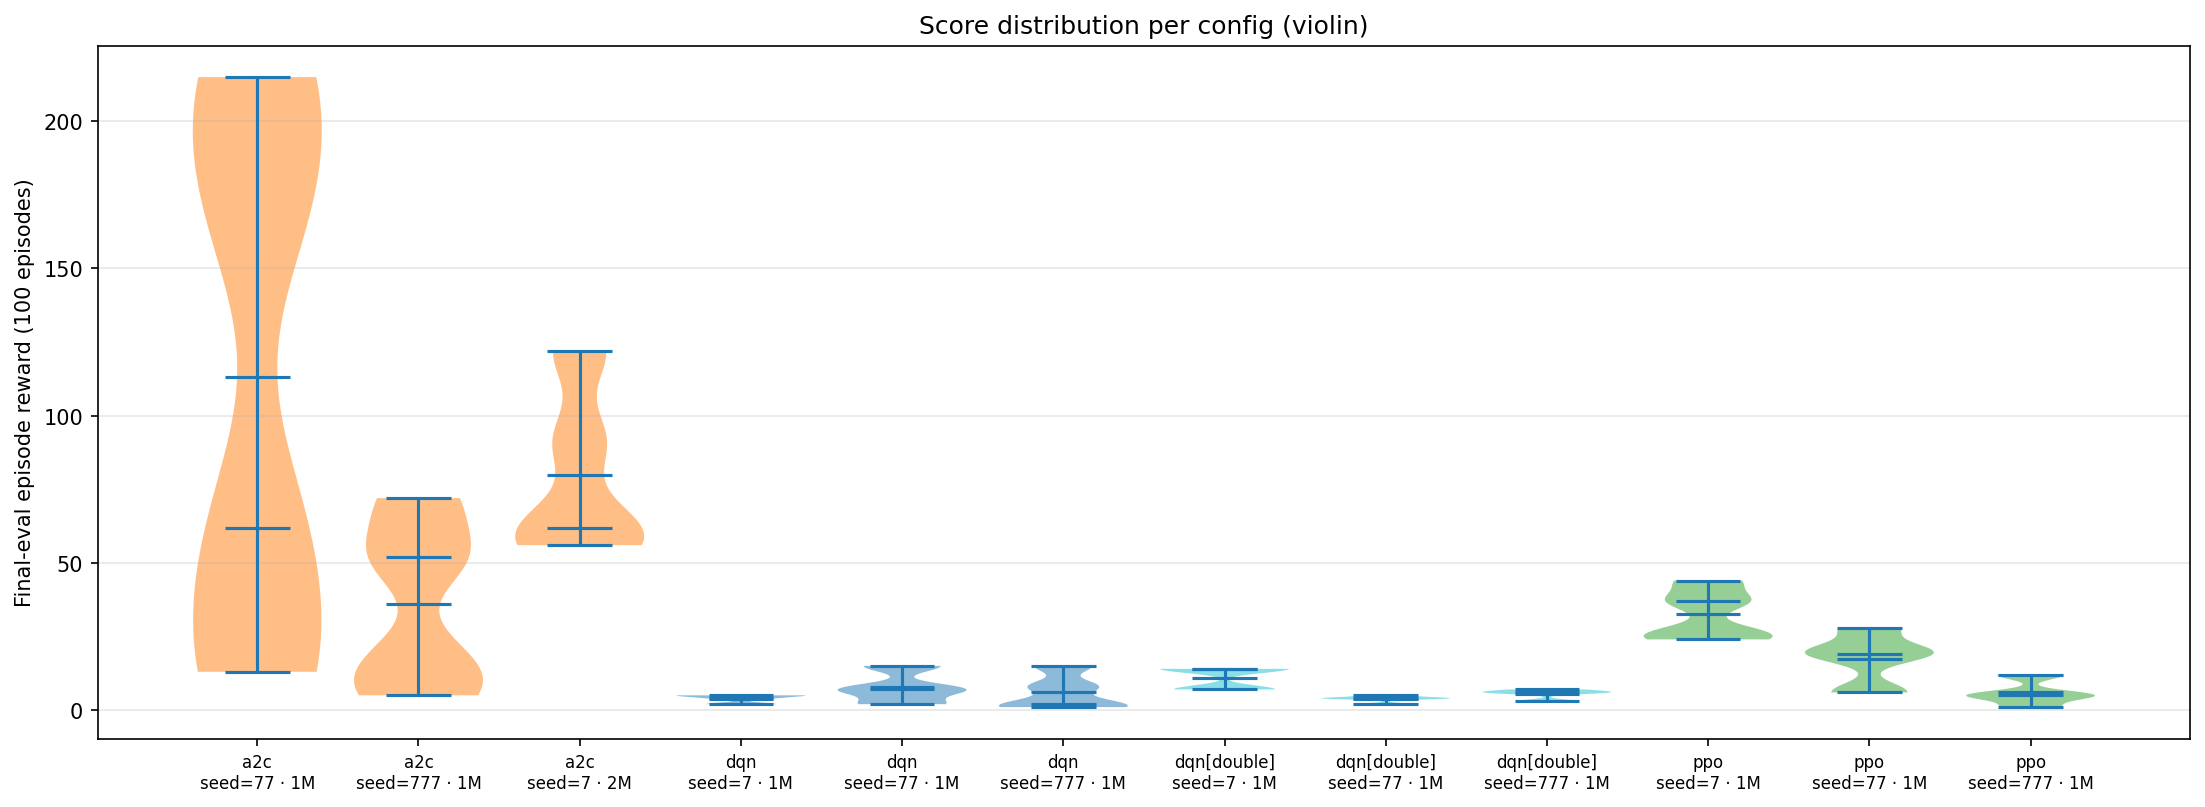

[plot] saved /home/lch/ws/Breakout_Final_Project_Pack/reports/figures/notebook/ecdf_1m.png


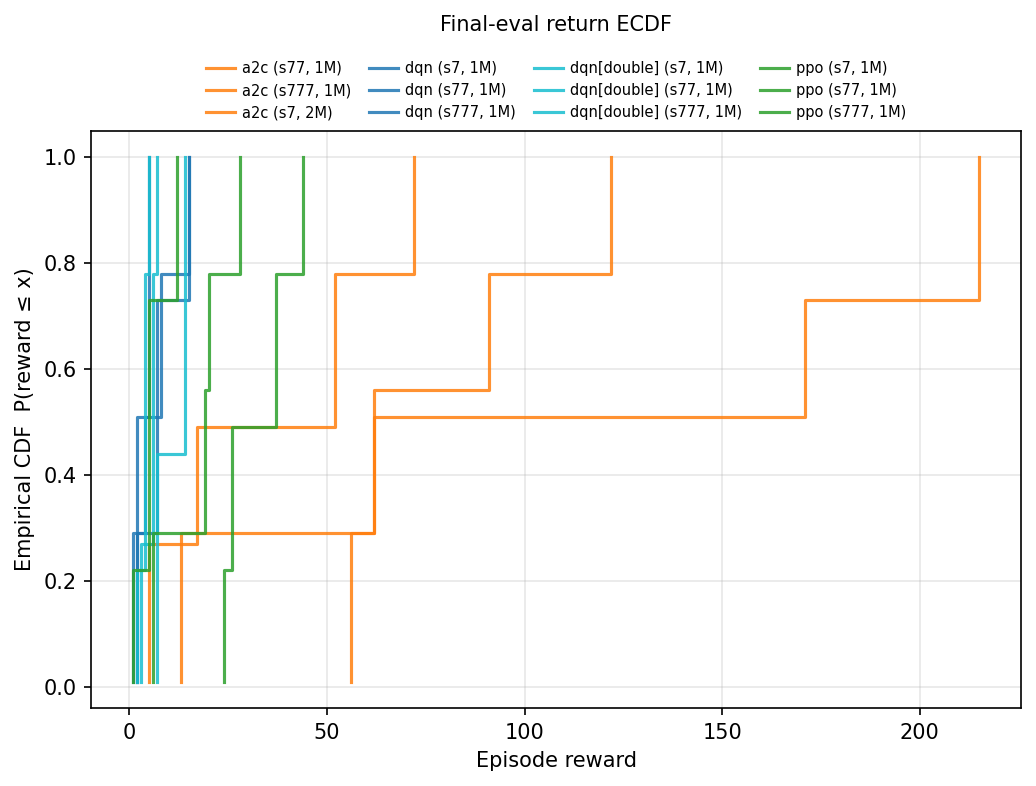

In [4]:
recs_1m = [r for r in records if r.bucket == "1m"]
show(P.plot_score_distributions, "violin_1m", recs=recs_1m, kind="violin")
show(P.plot_ecdf, "ecdf_1m", recs=recs_1m)

[plot] saved /home/lch/ws/Breakout_Final_Project_Pack/reports/figures/notebook/violin_2m.png


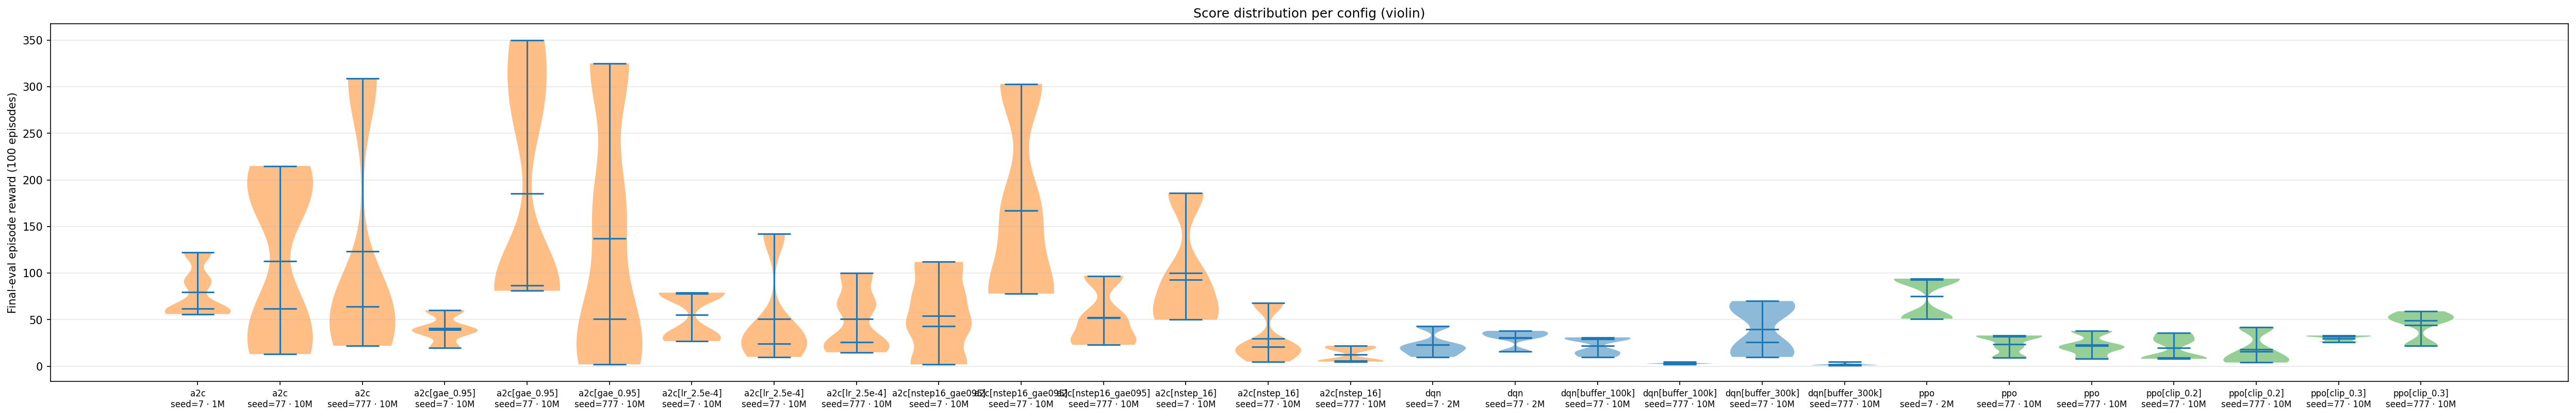

[plot] saved /home/lch/ws/Breakout_Final_Project_Pack/reports/figures/notebook/ecdf_2m.png


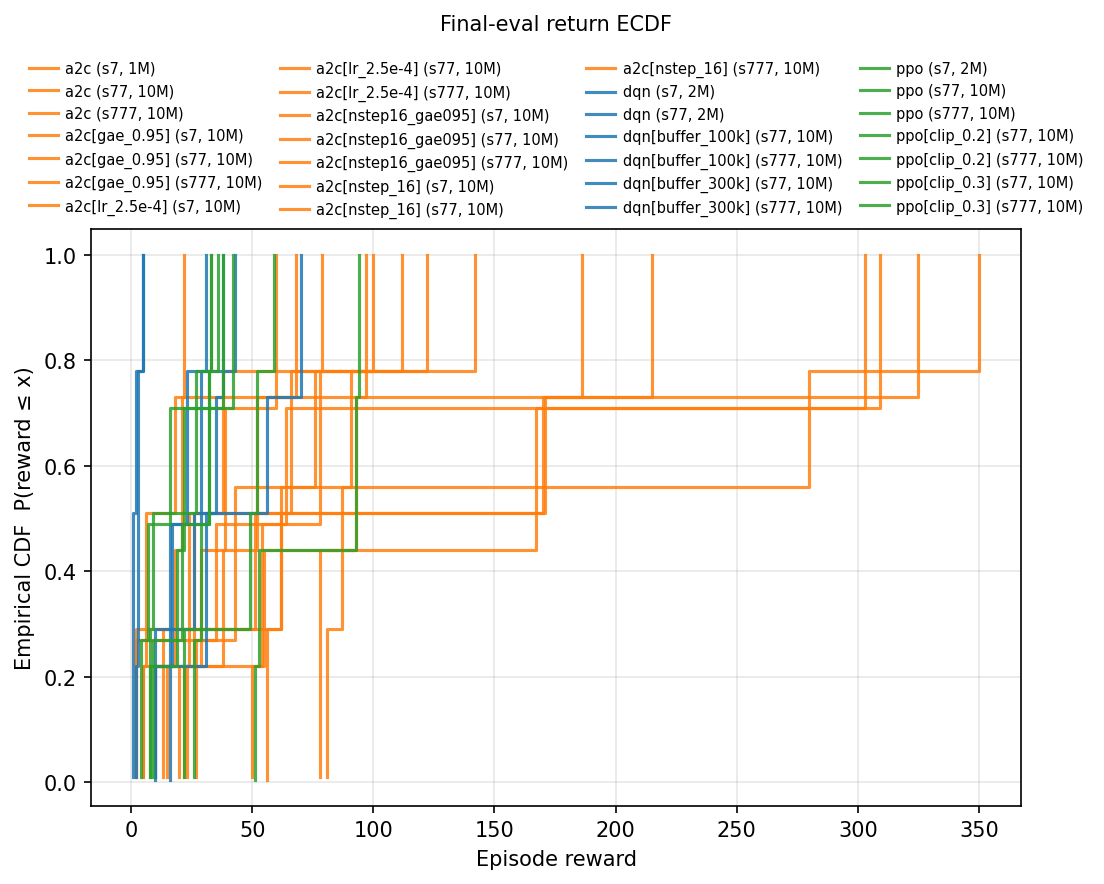

In [5]:
recs_2m = [r for r in records if r.bucket == "2m"]
show(P.plot_score_distributions, "violin_2m", recs=recs_2m, kind="violin")
show(P.plot_ecdf, "ecdf_2m", recs=recs_2m)

[plot] saved /home/lch/ws/Breakout_Final_Project_Pack/reports/figures/notebook/violin_10m.png


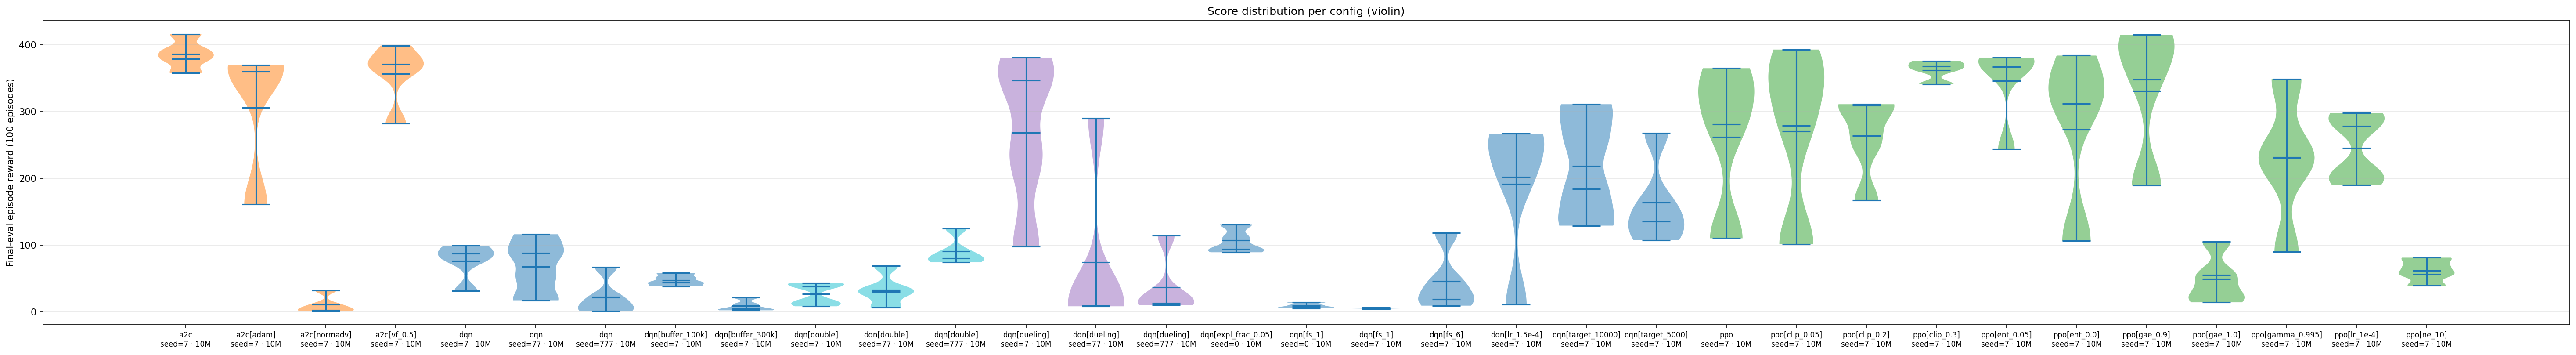

[plot] saved /home/lch/ws/Breakout_Final_Project_Pack/reports/figures/notebook/ecdf_10m.png


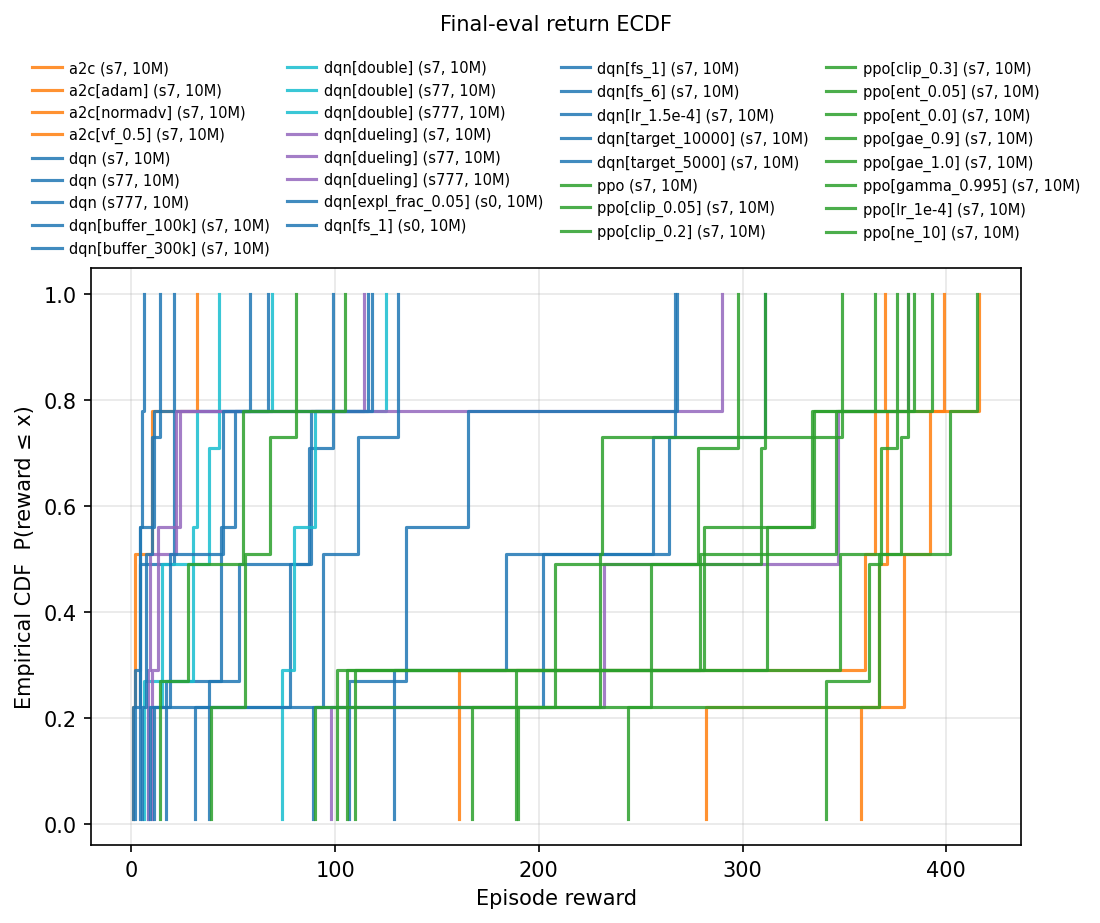

In [6]:
recs_10m = [r for r in records if r.bucket == "10m"]
show(P.plot_score_distributions, "violin_10m", recs=recs_10m, kind="violin")
show(P.plot_ecdf, "ecdf_10m", recs=recs_10m)

[plot] saved /home/lch/ws/Breakout_Final_Project_Pack/reports/figures/notebook/violin_50m.png


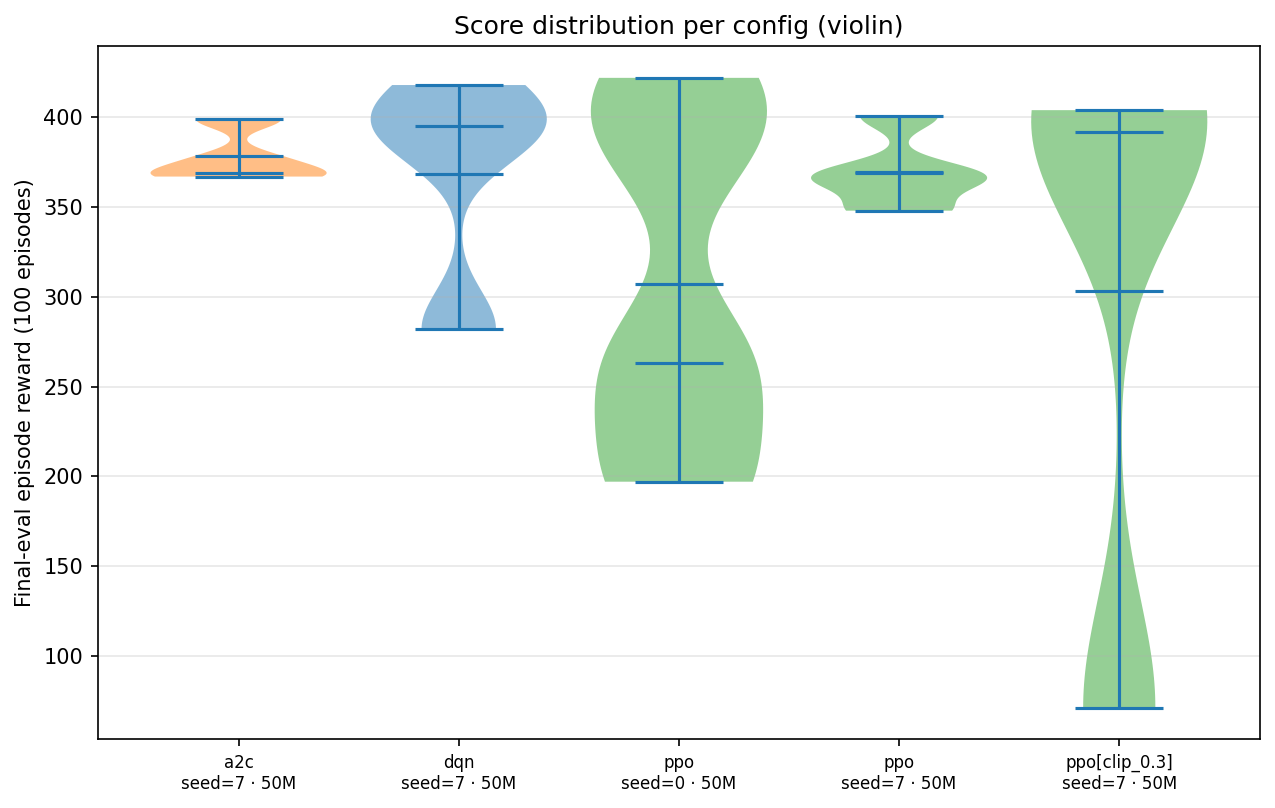

[plot] saved /home/lch/ws/Breakout_Final_Project_Pack/reports/figures/notebook/ecdf_50m.png


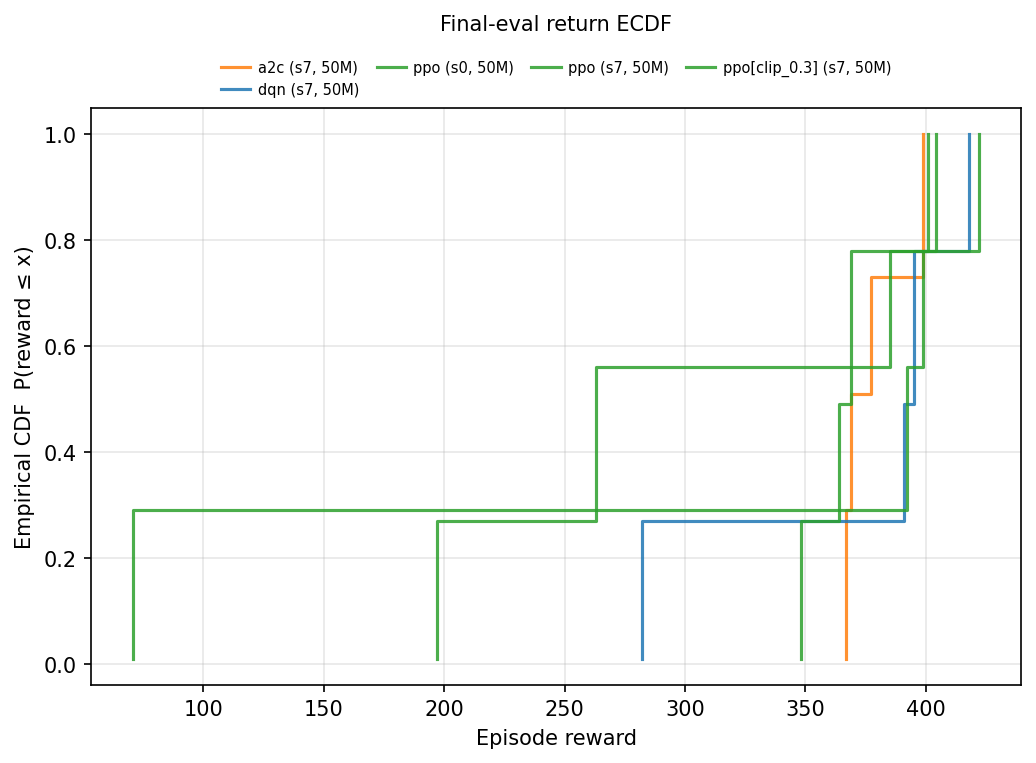

In [7]:
recs_50m = [r for r in records if r.bucket == "50m"]
show(P.plot_score_distributions, "violin_50m", recs=recs_50m, kind="violin")
show(P.plot_ecdf, "ecdf_50m", recs=recs_50m)

## Axis 3 — Timestep budget: learning curves
Eval reward vs environment steps. Curves use the in-training `evaluations.npz`;
the shaded band is ±std across seeds (only the multi-seed group shows a band).

[plot] saved /home/lch/ws/Breakout_Final_Project_Pack/reports/figures/notebook/learning_curves_1m.png


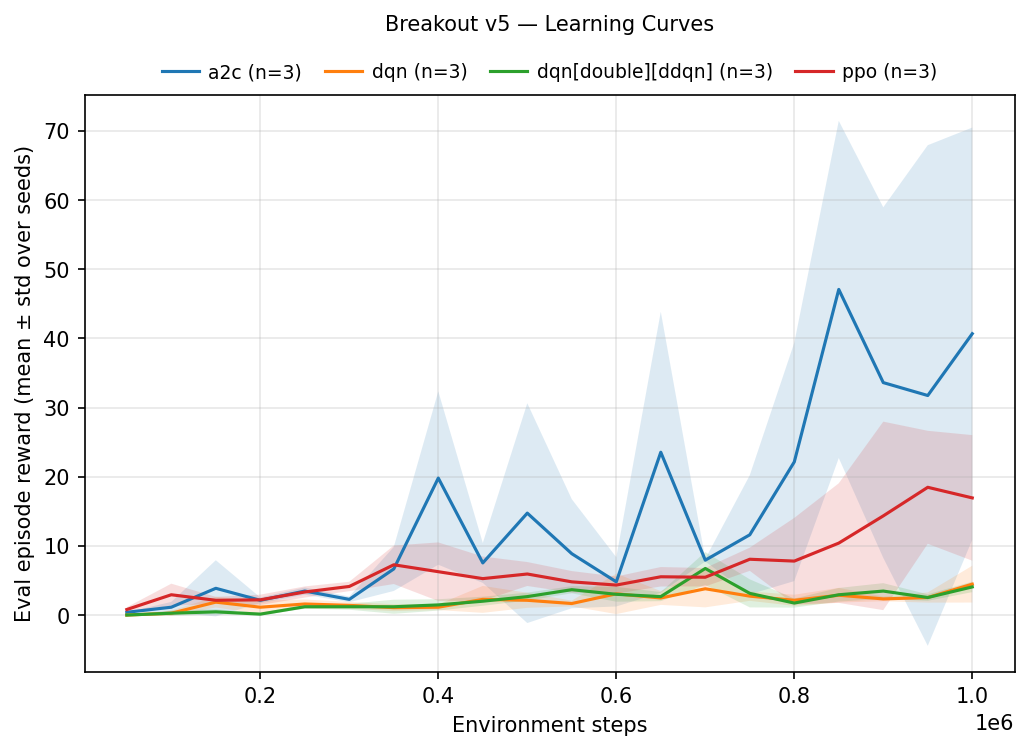

[plot] saved /home/lch/ws/Breakout_Final_Project_Pack/reports/figures/notebook/learning_curves_2m.png


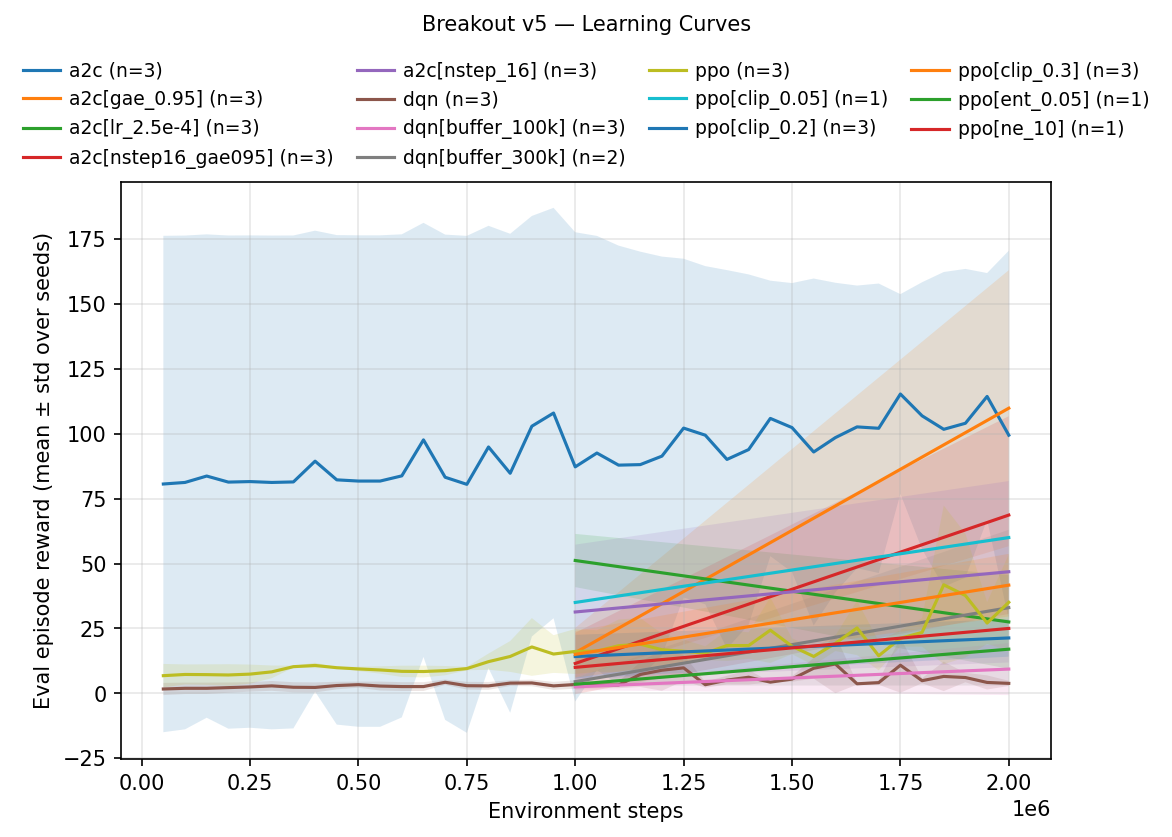

[plot] saved /home/lch/ws/Breakout_Final_Project_Pack/reports/figures/notebook/learning_curves_10m.png


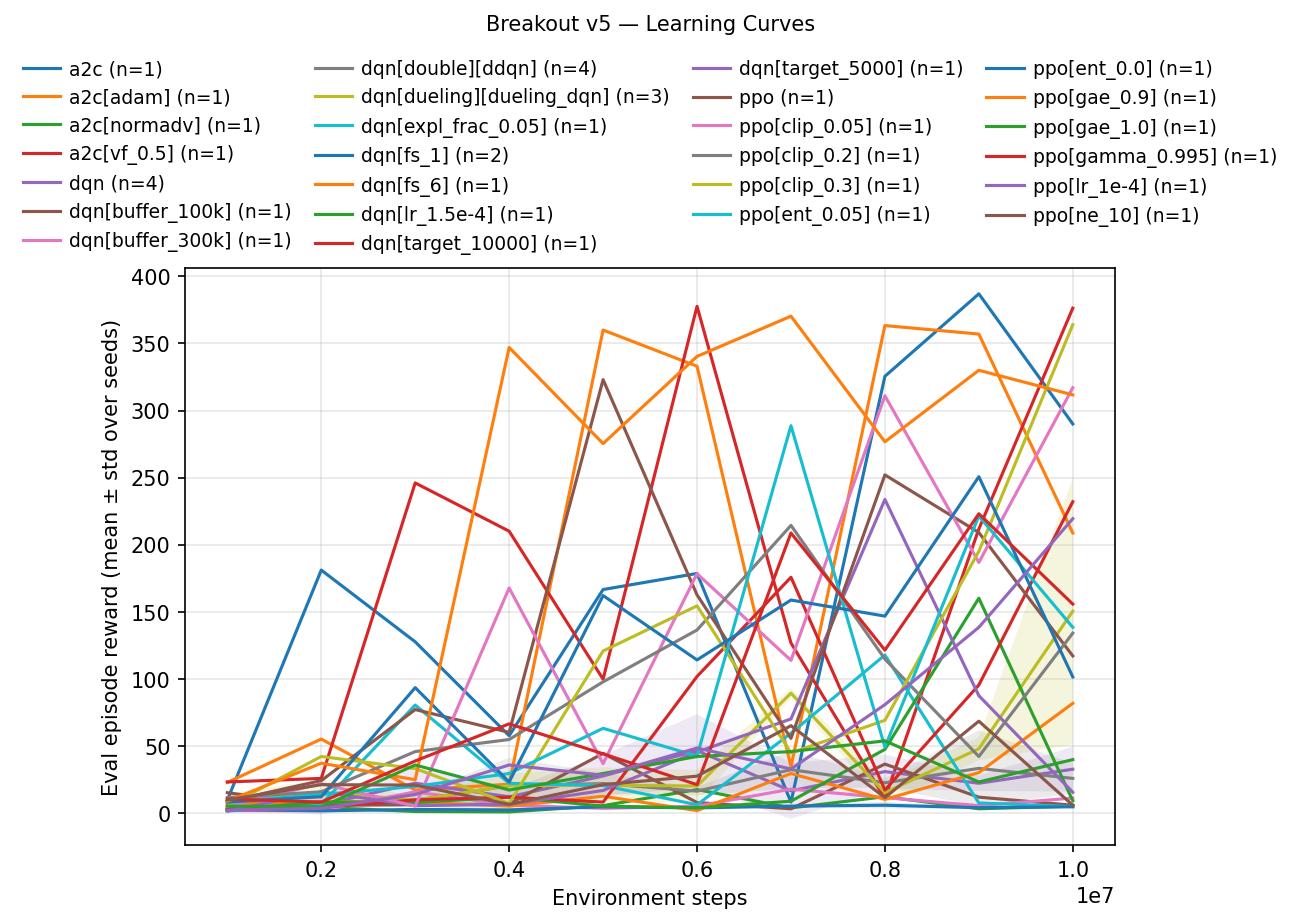

[plot] saved /home/lch/ws/Breakout_Final_Project_Pack/reports/figures/notebook/learning_curves_50m.png


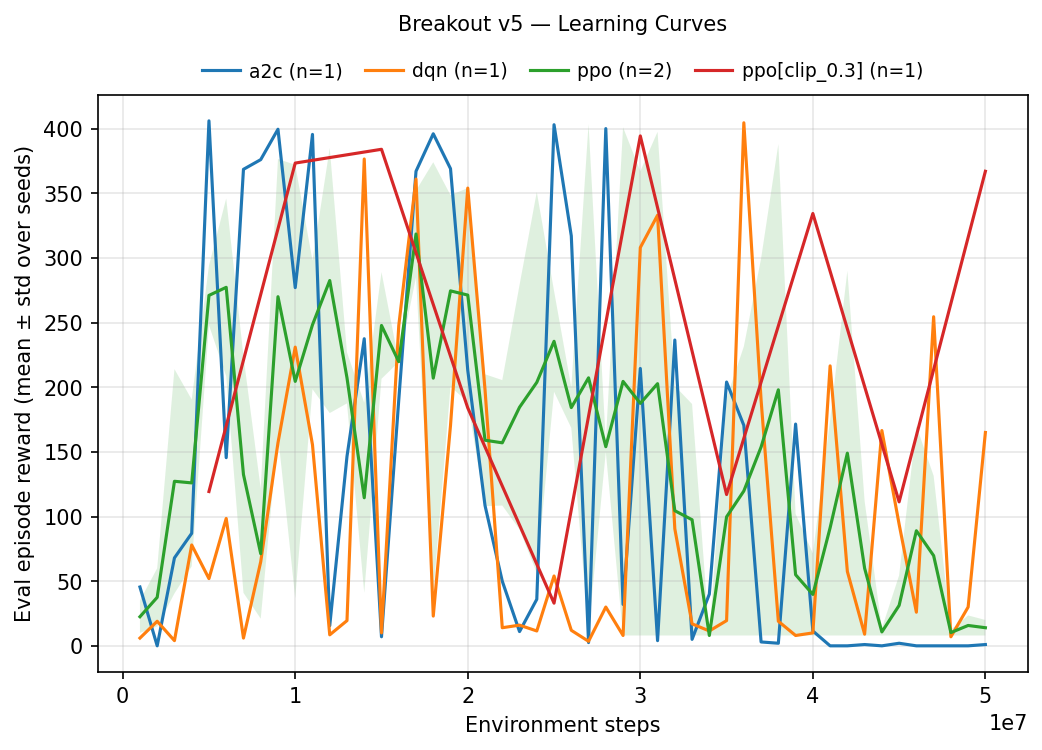

In [8]:
for g in ["1m", "2m", "10m", "50m"]:
    gp = ROOT / "experiments" / g
    if gp.exists():
        out = OUT / f"learning_curves_{g}.png"
        P.plot_learning_curves(P._collect_runs([gp]), out)
        display(Image(str(out)))

## Axis 4 — Hyperparameter response curves
Auto-detected single-variable sweeps (clip / ent / gae / lr / target / buffer / …).
Each panel is final-eval reward vs the knob value at a fixed budget, baseline included.

[plot] saved /home/lch/ws/Breakout_Final_Project_Pack/reports/figures/notebook/response_curves.png


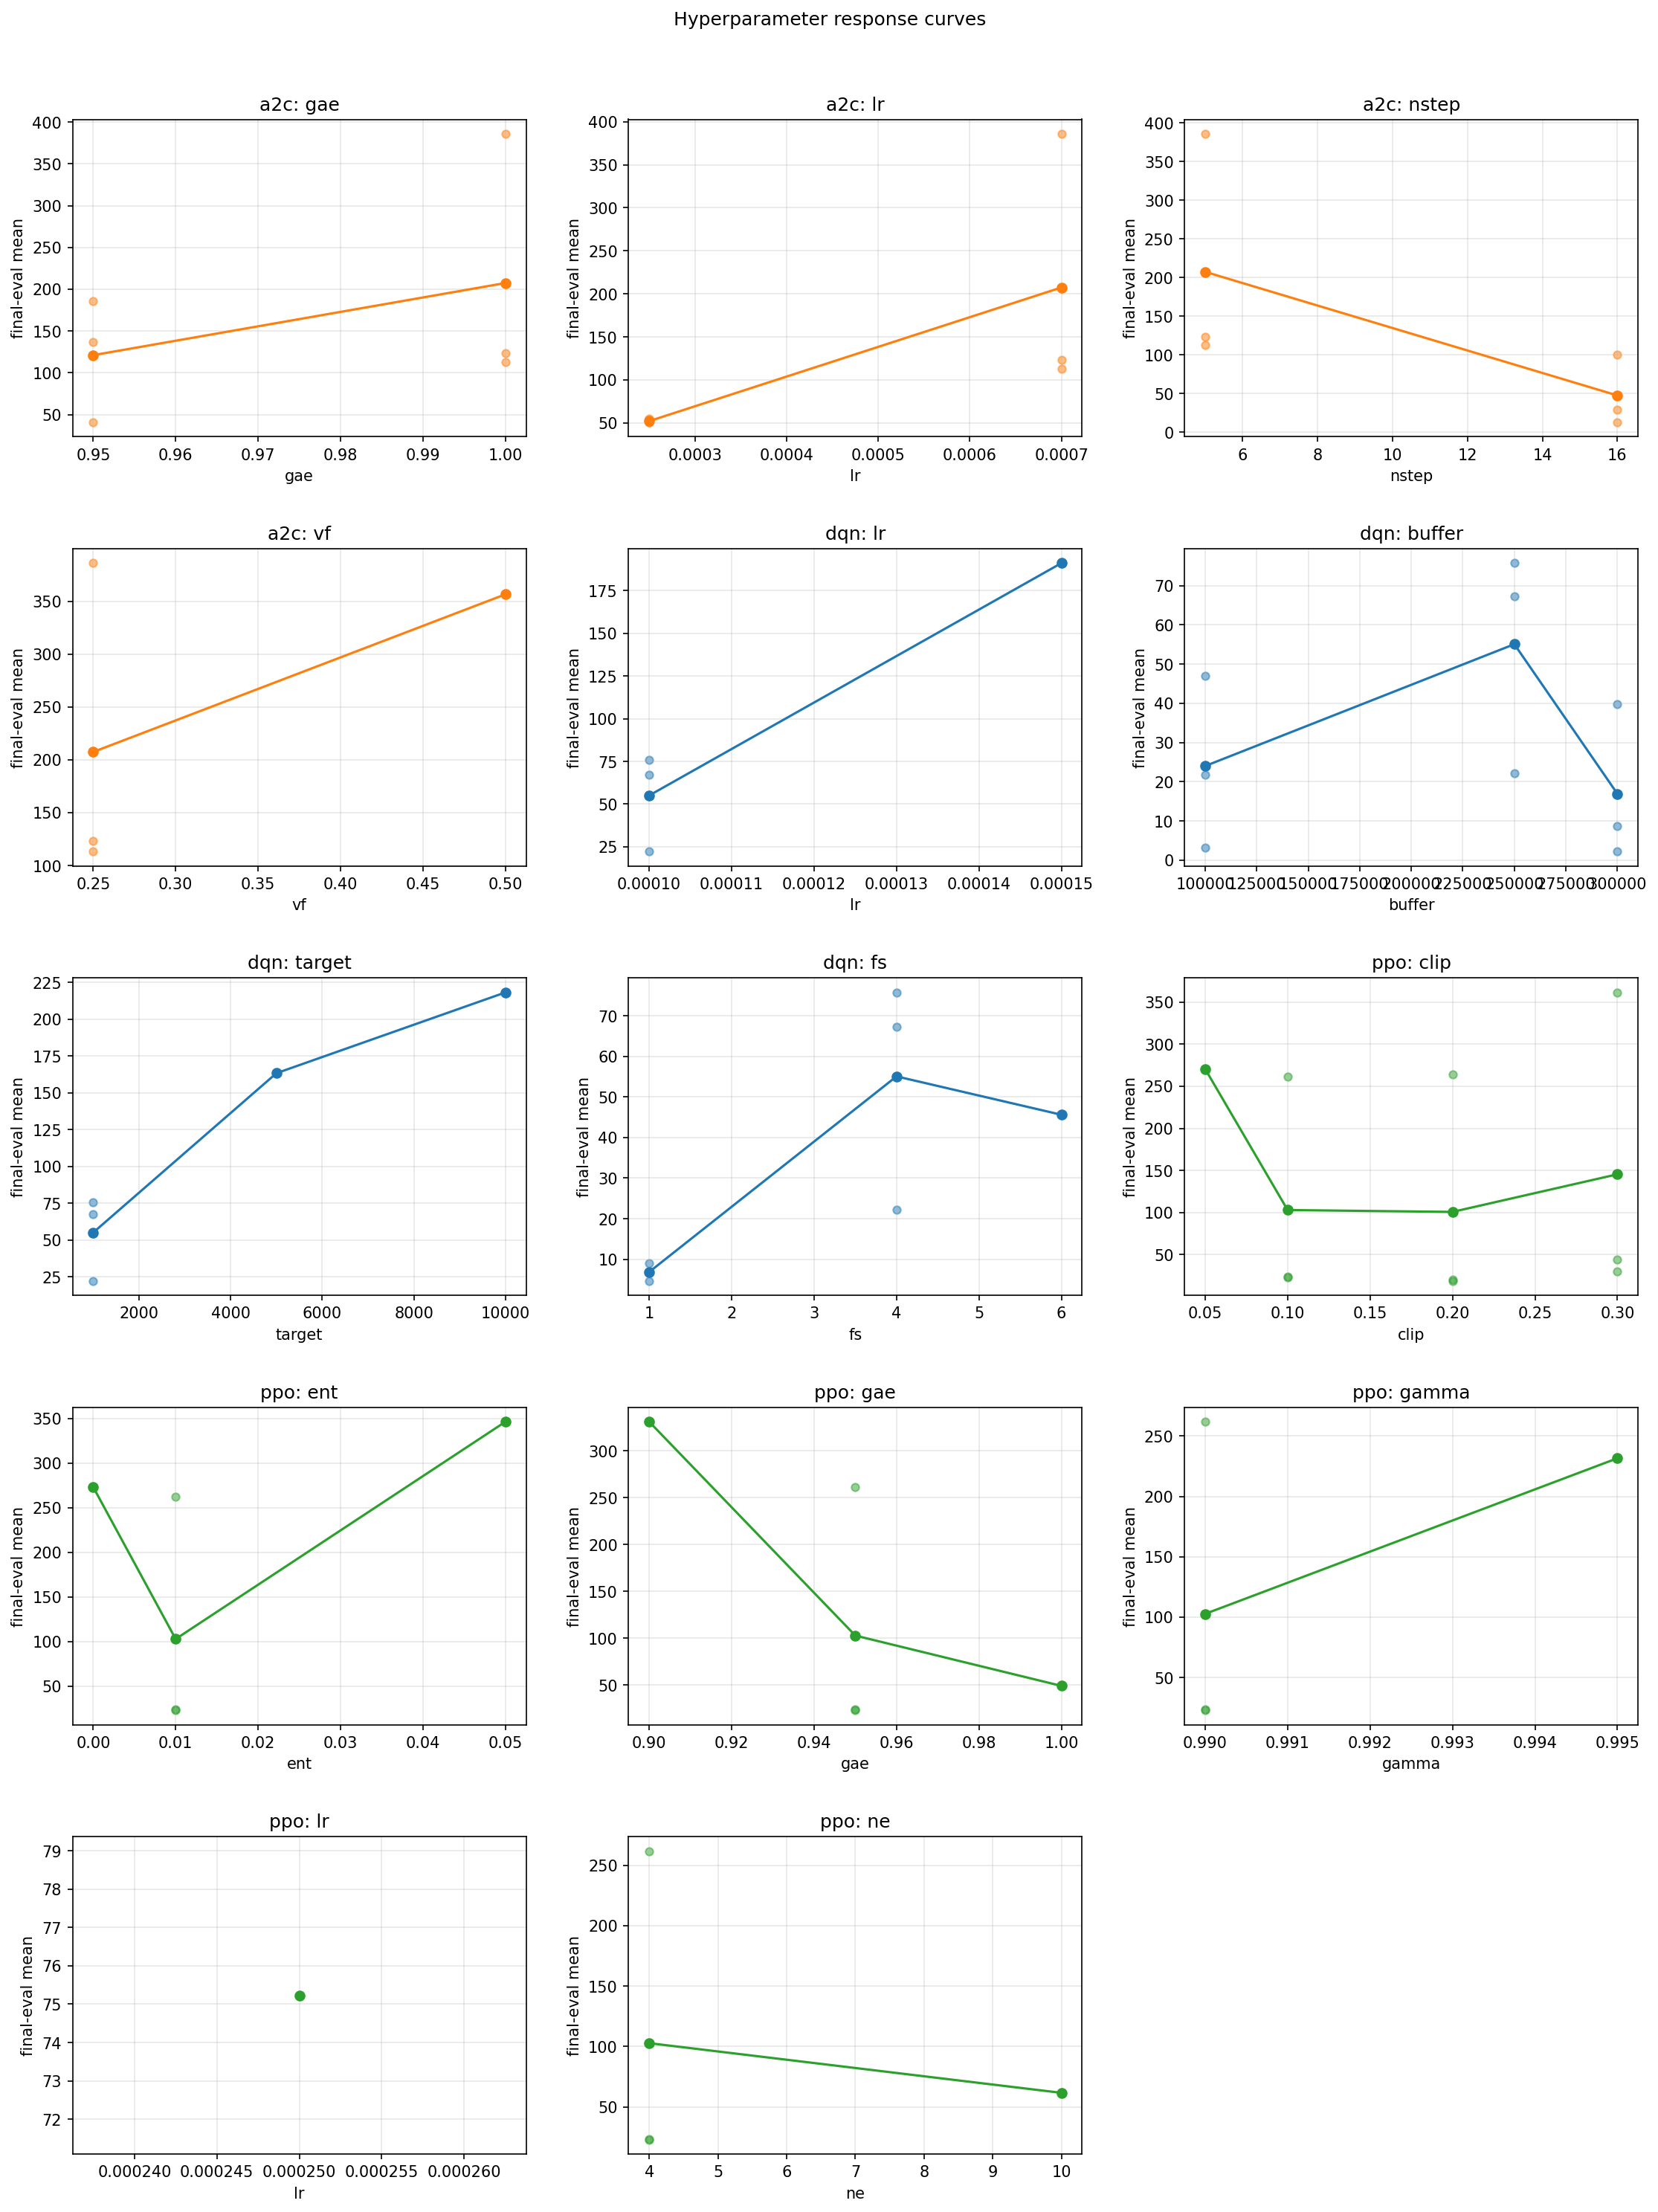

,variant,value,seed,budget,final_mean
1,clip_0.05,0.05,7,10000000,270.55
0,baseline,0.10,7,10000000,261.77
6,baseline,0.10,777,10000000,22.90
5,baseline,0.10,77,10000000,23.59
7,clip_0.2,0.20,77,10000000,19.51
2,clip_0.2,0.20,7,10000000,263.76
9,clip_0.2,0.20,777,10000000,18.32
3,clip_0.3,0.30,7,10000000,361.71
8,clip_0.3,0.30,77,10000000,29.94
10,clip_0.3,0.30,777,10000000,44.18


In [9]:
show(P.plot_response_curves, "response_curves")
# Inspect one sweep numerically, e.g. PPO clip_range:
A.hyperparameter_response(records, "ppo", "clip").round(2)

## Axis 5+6 — Sample efficiency & compute cost
Sample efficiency = how *much*, how *soon* (AUC + steps-to-threshold).
Compute trade-off = final score vs wall-clock hours (off-policy vs on-policy cost).

[plot] saved /home/lch/ws/Breakout_Final_Project_Pack/reports/figures/notebook/sample_efficiency_1m.png


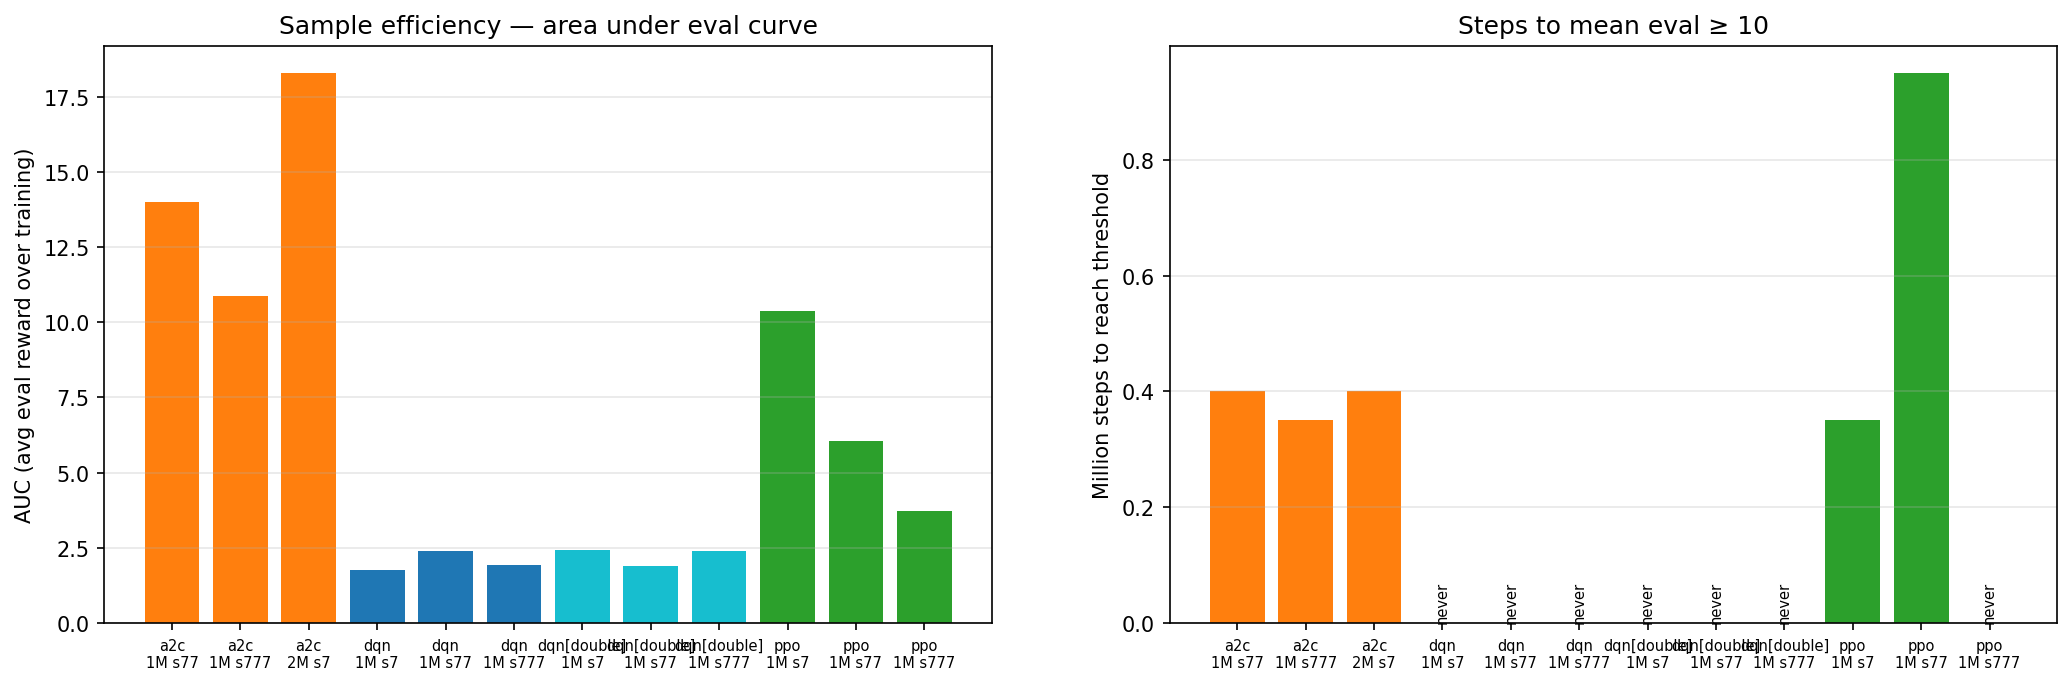

[plot] saved /home/lch/ws/Breakout_Final_Project_Pack/reports/figures/notebook/compute_tradeoff_1m.png


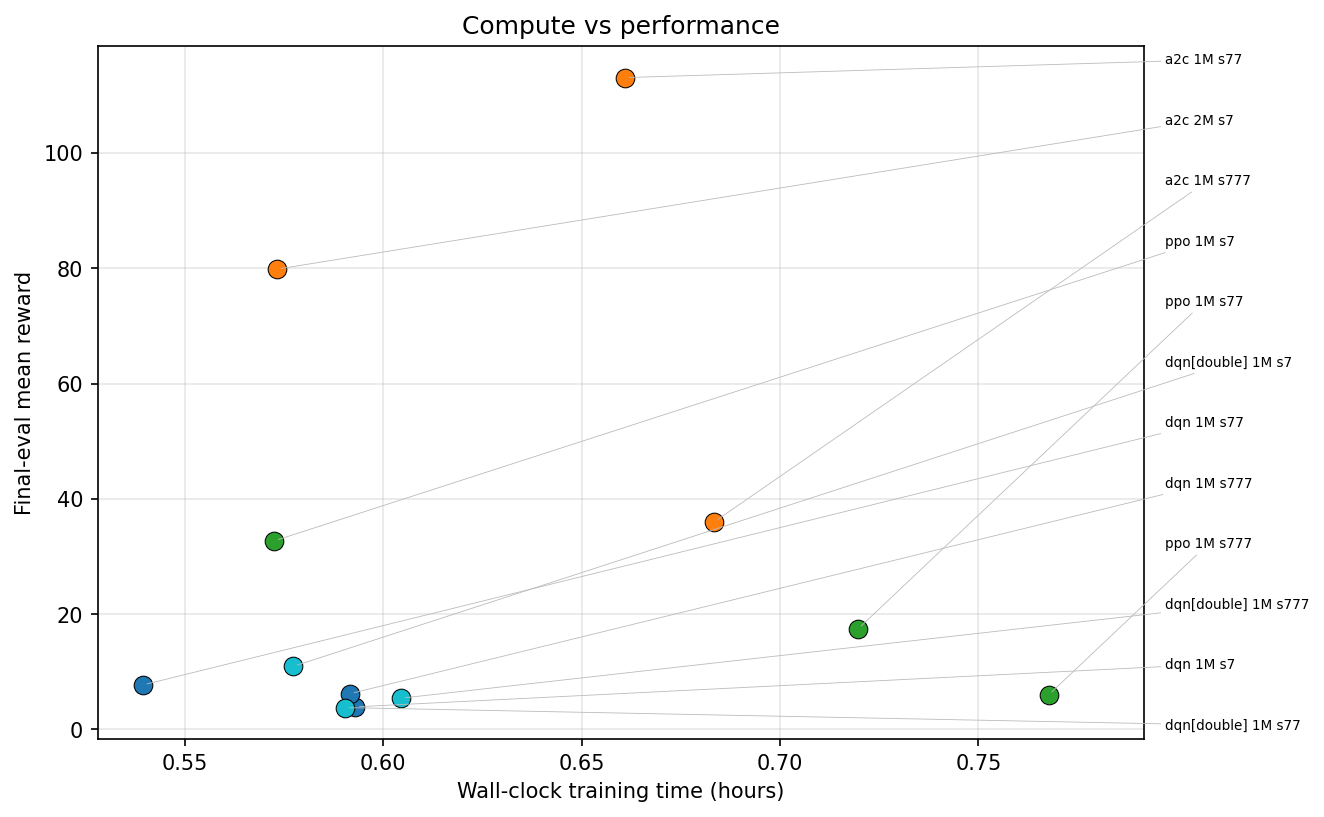

[plot] saved /home/lch/ws/Breakout_Final_Project_Pack/reports/figures/notebook/sample_efficiency_2m.png


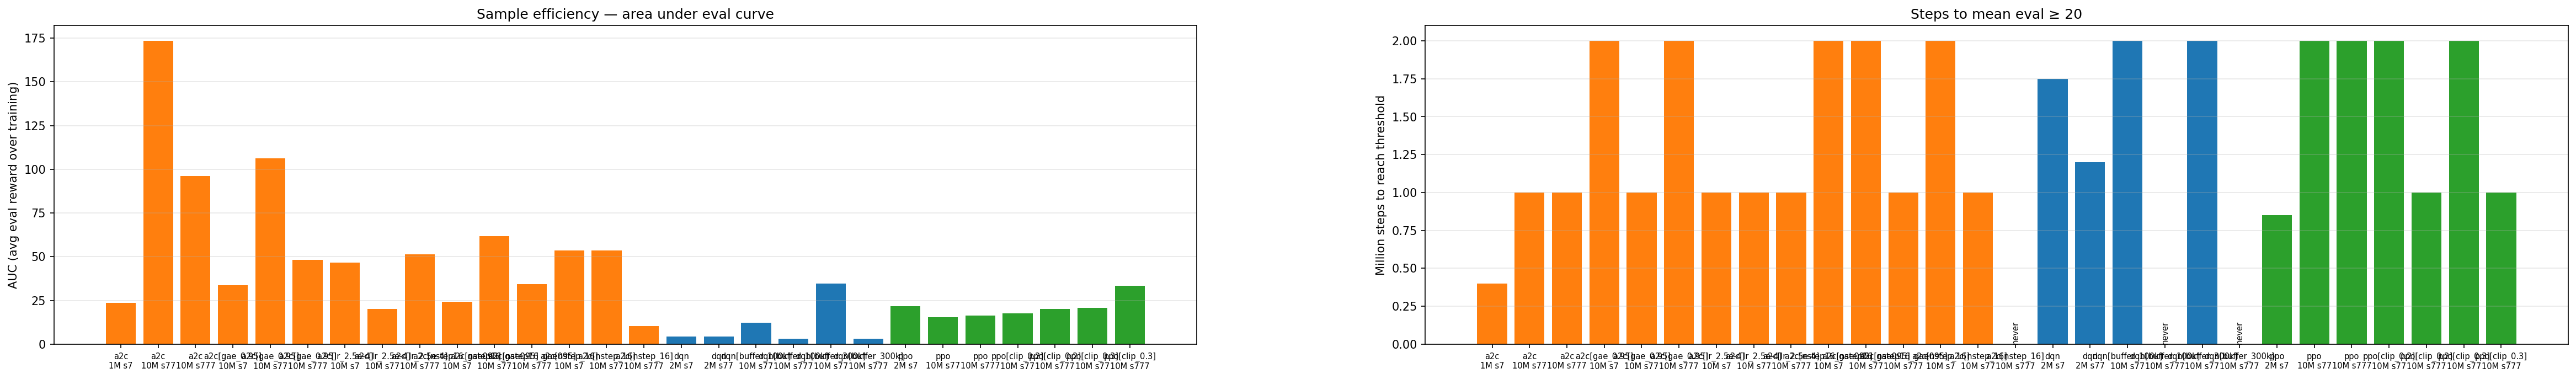

[plot] saved /home/lch/ws/Breakout_Final_Project_Pack/reports/figures/notebook/compute_tradeoff_2m.png


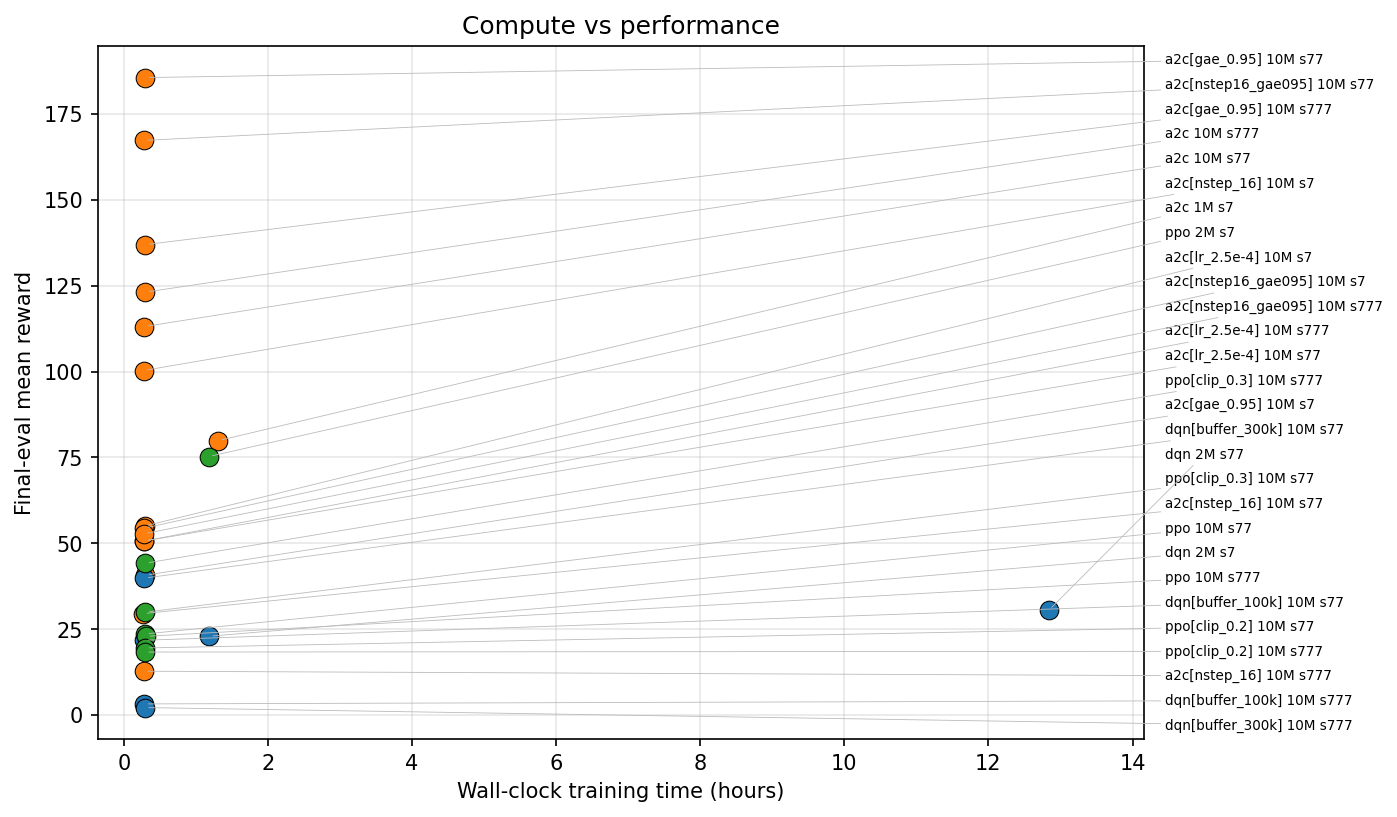

[plot] saved /home/lch/ws/Breakout_Final_Project_Pack/reports/figures/notebook/sample_efficiency_10m.png


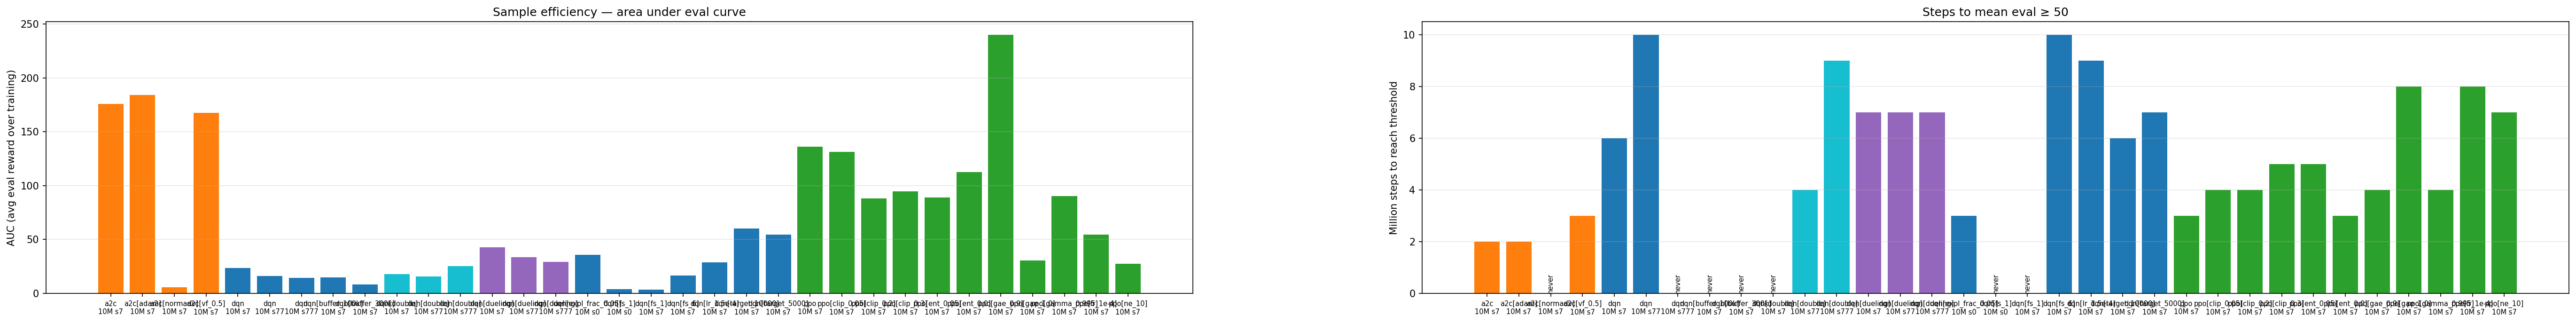

[plot] saved /home/lch/ws/Breakout_Final_Project_Pack/reports/figures/notebook/compute_tradeoff_10m.png


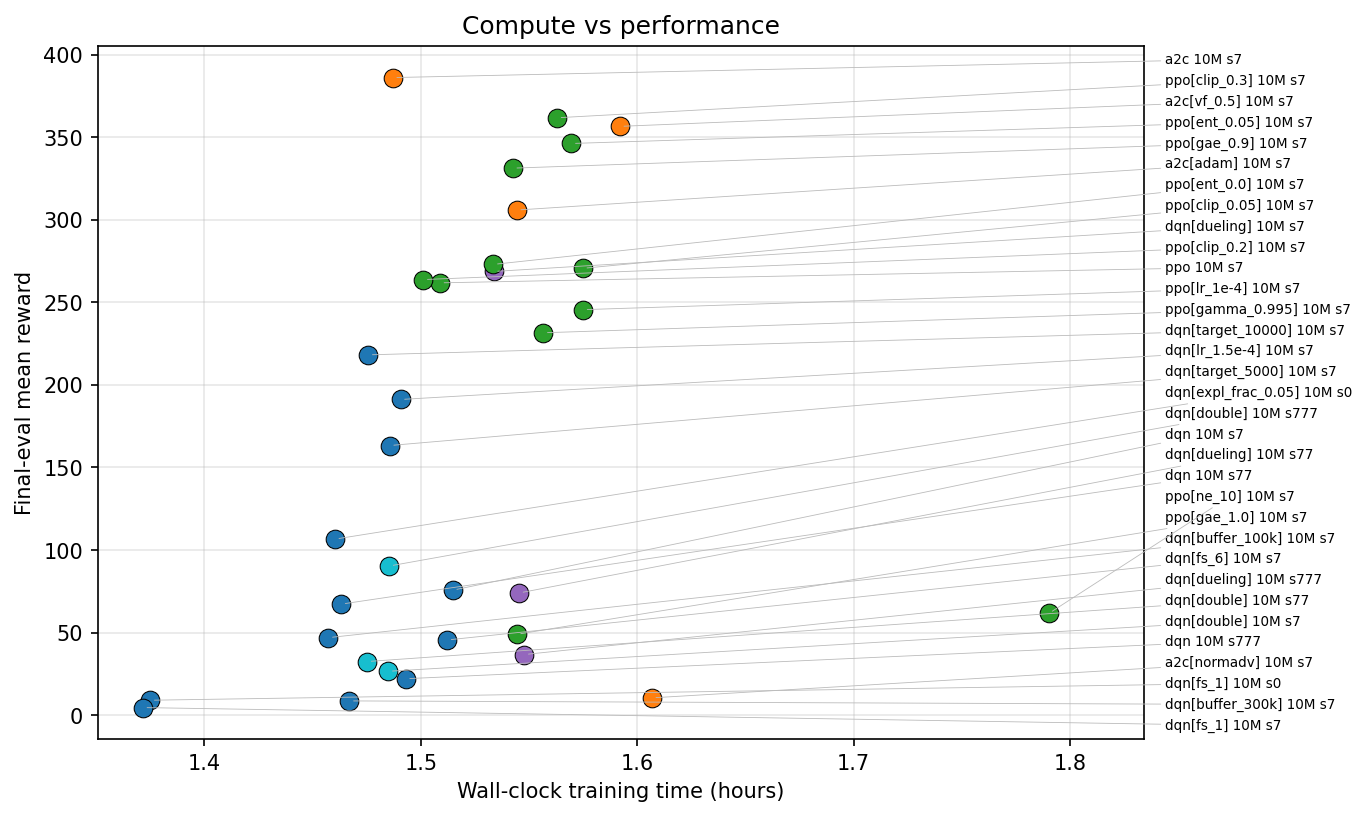

[plot] saved /home/lch/ws/Breakout_Final_Project_Pack/reports/figures/notebook/sample_efficiency_50m.png


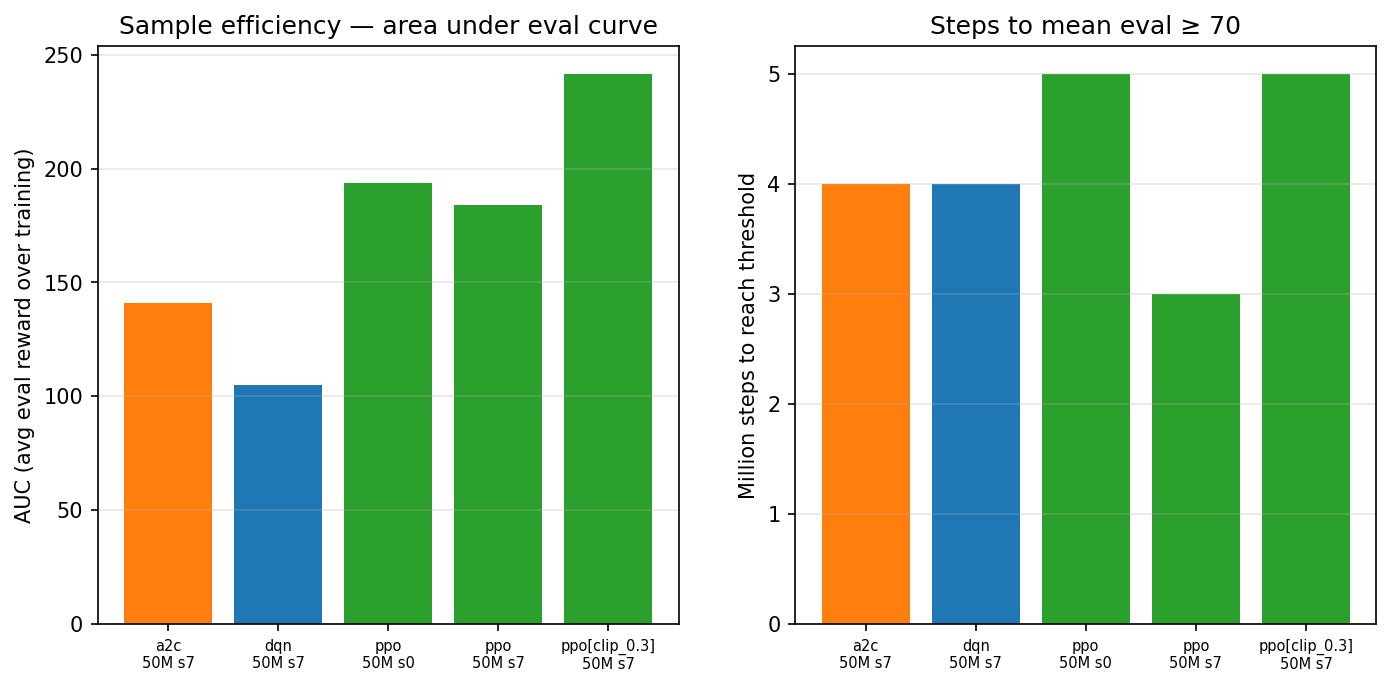

[plot] saved /home/lch/ws/Breakout_Final_Project_Pack/reports/figures/notebook/compute_tradeoff_50m.png


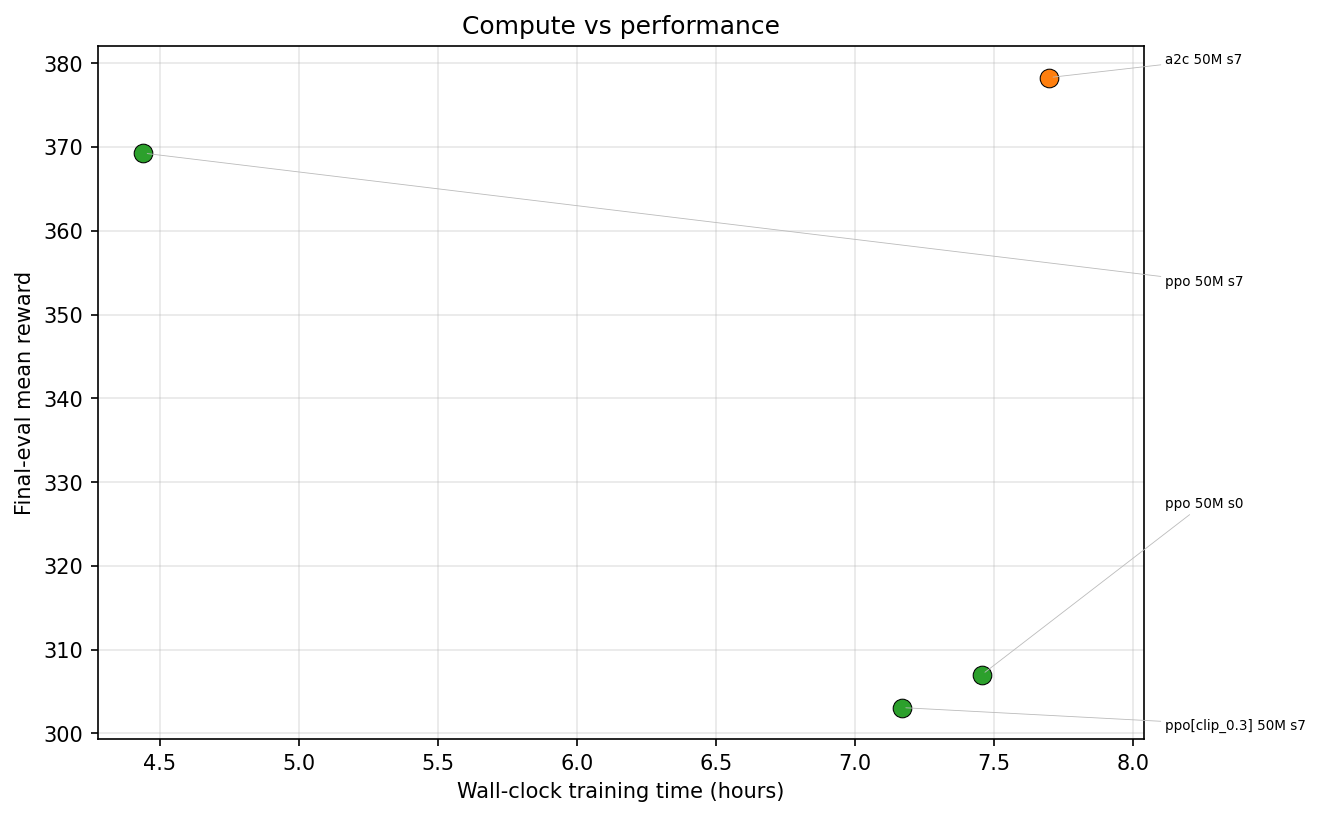

In [10]:
show(P.plot_sample_efficiency, "sample_efficiency_1m", recs=recs_1m, threshold=10)
show(P.plot_compute_tradeoff, "compute_tradeoff_1m", recs=recs_1m)

show(P.plot_sample_efficiency, "sample_efficiency_2m", recs=recs_2m, threshold=20)
show(P.plot_compute_tradeoff, "compute_tradeoff_2m", recs=recs_2m)

show(P.plot_sample_efficiency, "sample_efficiency_10m", recs=recs_10m, threshold=50)
show(P.plot_compute_tradeoff, "compute_tradeoff_10m", recs=recs_10m)

show(P.plot_sample_efficiency, "sample_efficiency_50m", recs=recs_50m, threshold=70)
show(P.plot_compute_tradeoff, "compute_tradeoff_50m", recs=recs_50m)

## Axis 8 — Statistical significance (eval-level)
P(row > col) over the 100 eval episodes of one model per config, at the largest
shared budget. **Caveat:** this is episode variance of single trained models, not
a training-seed test — it shows how separated two *policies* are, not that one
*algorithm* beats another in general.

[plot] saved /home/lch/ws/Breakout_Final_Project_Pack/reports/figures/notebook/significance.png


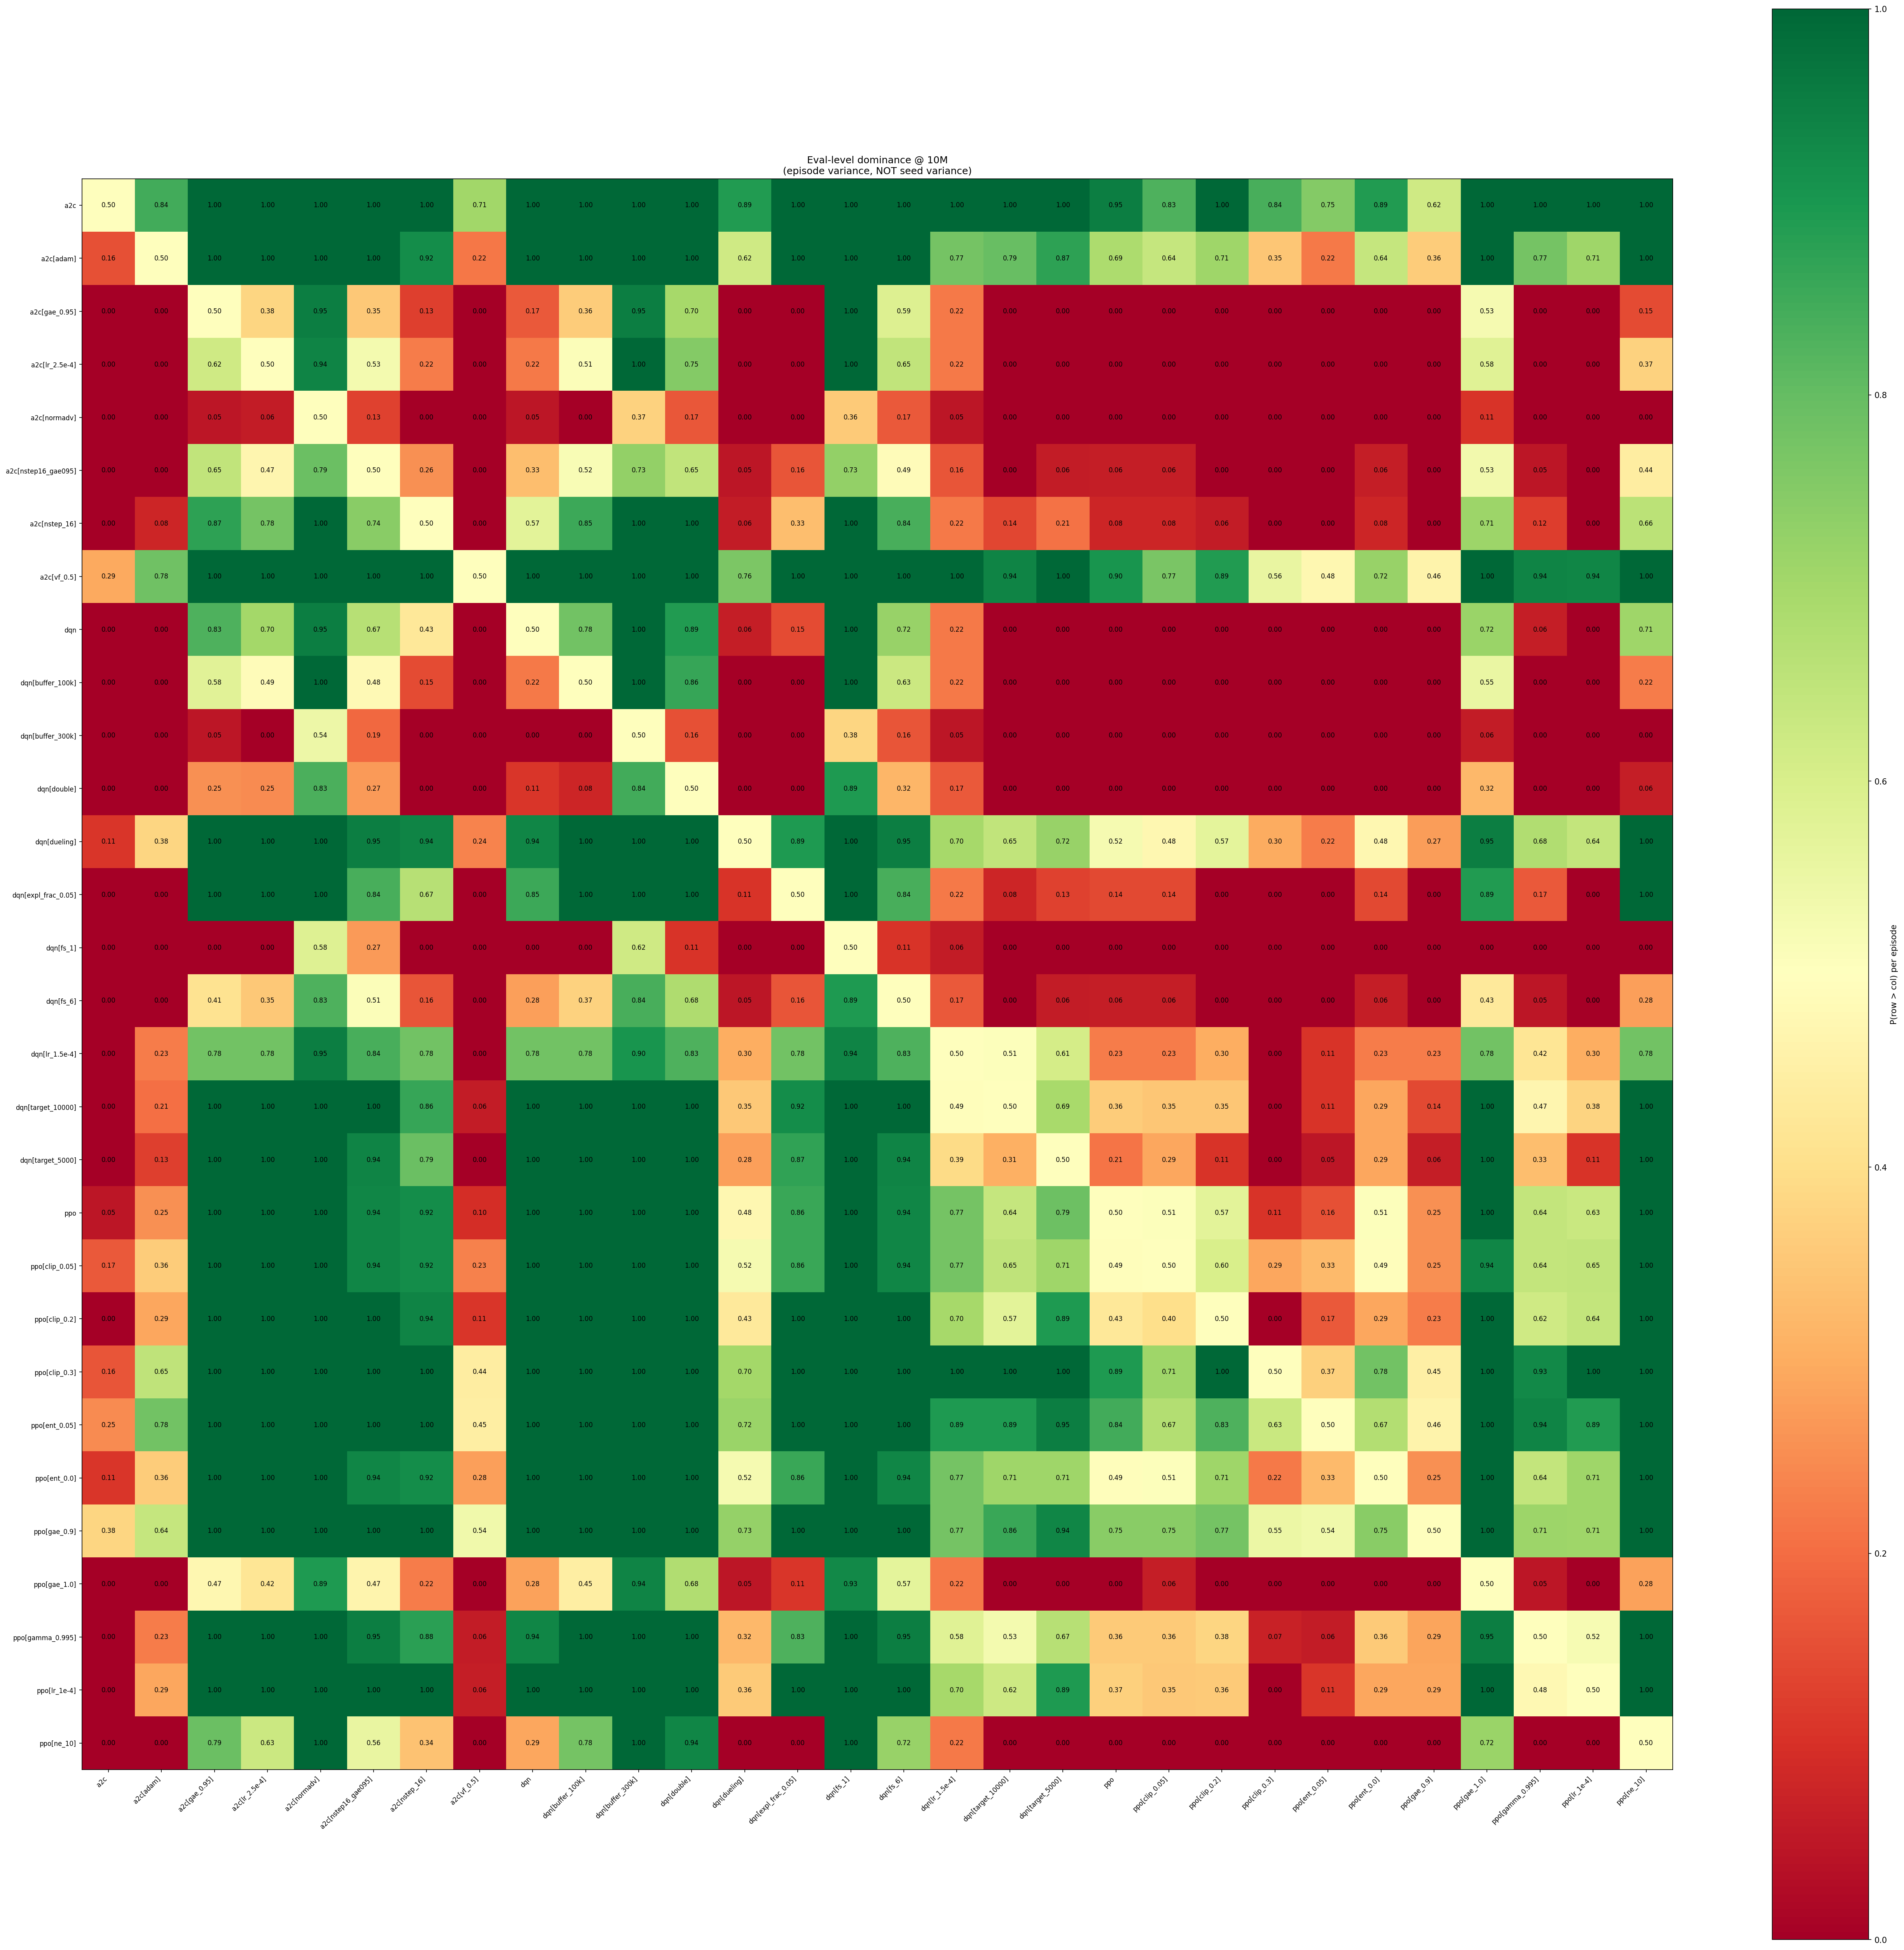

In [11]:
show(P.plot_significance_heatmap, "significance")
# Pairwise detail for any two runs (Mann-Whitney U + bootstrap diff + P(A>B)):
r10 = [r for r in records if r.bucket == "10m"]
by = {r.label: r for r in r10}
if "ppo" in by and "dqn" in by:
    A.pairwise_significance(by["ppo"], by["dqn"])

## How to read these for the report
- **Don't rank on `final_mean` alone.** A high mean with a high `tail_std` (unstable),
  a `cap_rate`≈1 (survives by stalling, not scoring), or `n_seeds=1` (luck) is weaker
  evidence than a slightly lower but stable, multi-seed result.
- **Sample efficiency vs final score** separates "fast learner" from "high ceiling".
- **Compute trade-off** justifies algorithm choice under a fixed time budget.
- **Response curves** justify each hyperparameter as too-low → baseline → too-high.
- **Significance** quantifies whether a gap is real at the episode level; pair it with
  the cross-seed aggregate to argue about the *algorithm*, not just one model.